In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
from mad.configs.ballistic_objects import titan_stage_1, titan_stage_2
from mad.configs.planets import EARTH_SETTINGS
from mad.objs.planets import Planet, PlanetConfig
from mad.objs.missiles import BallisticMissileConfig, MissileStage, MissileStageConfig, BallisticMissile, Payload
from mad.objs.guidances import GravityTurn, ClosedFormBallistic, RangeGuided
from mad.logger import SourceLogger


logger = SourceLogger()

In [46]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.create_2D_point(name="Launchpad", altitude=10)
target = earth.create_2D_point_at_distance(launchpad, distance_km=8_000, name="Target")

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [47]:
stage1_cfg = MissileStageConfig(**titan_stage_1)
stage2_cfg = MissileStageConfig(**titan_stage_2)

stage_guidance = RangeGuided(planet=earth, target=target, ballistic_table_path="titan_stage_2")

stage1 = MissileStage(stage1_cfg)
stage2 = MissileStage(stage2_cfg)

guidance = ClosedFormBallistic(planet=earth, target=target)
missile_cfg = BallisticMissileConfig(stages=[stage1, stage2], guidance=stage_guidance)
titan = BallisticMissile(position=launchpad.position.copy(), cfg=missile_cfg, name="Titan I")

titan

/app/src/mad/objs/guidances.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  from abc import ABC, abstractmethod


BallisticMissile Titan I, active.
Stages: Stage1, Stage2.
Available deltaV: 11818.37 m/s.
Burned Fraction: 0.00.

In [48]:
dt = 1
max_time = 20000
active_objs = [titan]
inactive_objs = []
t = 0.0
logger["Simulation"].info("Starting simulation.")
while (t < max_time) or any(obj.active for obj in active_objs):
    new_objects = []

    for obj in active_objs[:]:

        if not obj.active:
            continue

        sim_update = obj.update(dt)

        if sim_update is not None:
            new_objects.append(sim_update)
            logger["Simulation"].info(f"{sim_update.name} added to Simulation.")

        if not obj.active:
            continue
        obj.integrate(dt, earth)

    active_objs.extend(new_objects)
    t += dt
logger["Simulation"].info(f"Simulation ended at t={t:.2f} seconds.")

21:19:42 | INFO     | Simulation   | Starting simulation.
21:19:42 | INFO     | Missile      | Stage1 ran out of propellant at 110.00.
21:19:42 | INFO     | Missile      | Titan I - Stage1 separated at 110.00.
21:19:42 | INFO     | Simulation   | Stage1 added to Simulation.
21:19:42 | INFO     | Guidance     | Titan I switched to ballistic phase at range 7478642.75 m (optimal: 8454612.19 m).
21:19:42 | INFO     | Missile      | Titan I switched to ballistic phase at 327.00.
21:19:42 | INFO     | Missile      | Titan I - Stage2 separated at 327.00.
21:19:42 | INFO     | Missile      | Titan I inactivated at 327.00.
21:19:42 | INFO     | Simulation   | Stage2 added to Simulation.
21:19:43 | INFO     | Projectile   | Stage1 landed on the ground!
21:19:43 | INFO     | Projectile   | Stage2 landed on the ground!
21:19:43 | INFO     | Simulation   | Simulation ended at t=20000.00 seconds.


In [49]:
def extract_history(objs:list, planet:Planet=earth):

    results = {}
    for obj in objs:
        pos = np.asarray(obj.history.position)
        vel = np.asarray(obj.history.velocity)
        time = np.asarray(obj.history.time)

        posx, posz = pos[:, 0], pos[:, 1]

        r = np.linalg.norm(pos, axis=1)
        velout = np.linalg.norm(vel, axis=1)

        energy = 0.5 * velout**2 - planet.mu / r
        altitude = r - planet.radius

        results[obj.name] = {"time": time, "altitude": altitude, "velocity":velout, "posx":posx, "posz":posz, "energy":energy}

    return results

results = extract_history(active_objs, planet=earth)
results.keys()

dict_keys(['Titan I', 'Stage1', 'Stage2'])

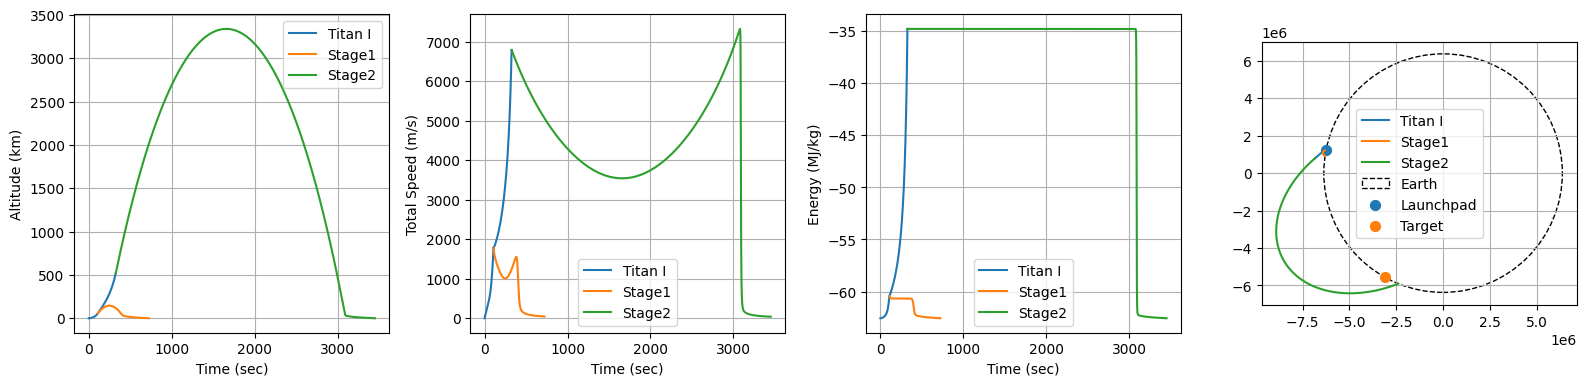

In [50]:
fig, ax = plt.subplots(ncols=4, nrows=1, figsize=(16, 4))
ax.flatten()

for obj, result in results.items():

    ax[0].plot(result["time"], result["altitude"] / 1000, label=obj)
    ax[1].plot(result["time"], result["velocity"], label=obj)
    ax[2].plot(result["time"], result["energy"] / 1000_000, label=obj)
    ax[3].plot(result["posx"], result["posz"], label=obj)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")
ax[0].grid()
ax[0].legend()

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].legend()
ax[1].grid()

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Energy (MJ/kg)")
ax[2].legend()
ax[2].grid()

earth.plot_2D_with_points(points = [launchpad, target], ax=ax[3])


fig.tight_layout(pad=1.2)

In [51]:
f"Distance Impact to target: {earth.surface_distance(target, active_objs[2]) / 1000:.2f} km"

'Distance Impact to target: 782.78 km'